# 📊 NOTEBOOK 09 : FIGURES HAUTE QUALITÉ POUR PUBLICATION

## Contexte
Génération de figures **publication-ready** respectant les standards des revues scientifiques :
- Résolution ≥ 300 DPI (Nature, Science, PNAS)
- Format vectoriel (.pdf) ou haute résolution (.png)
- Police lisible (≥8pt), légendes complètes, unités explicites
- Palettes couleur accessible (colorblind-friendly)
- Multi-panneaux avec légendes A, B, C, D...

## Figures générées
1. **Figure 1** : Pipeline complet (01→09) — diagramme méthodologique
2. **Figure 2** : Performances comparées (barplot R², RMSE, MAE)
3. **Figure 3** : Feature Importance + SHAP summary (meilleur modèle)
4. **Figure 4** : Prédictions vs Observations + résidus + QQ-plot
5. **Figure 5** : Validation croisée + Bootstrap IC95%

## Références stylistiques
- Rougier et al. (2014). *Ten Simple Rules for Better Figures*. PLOS Comput Biol.
- Tufte, E. (2001). *The Visual Display of Quantitative Information*.


In [12]:
# ============================================================
# 📦 IMPORTS ET CONFIGURATION
# ============================================================
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
from scipy.stats import norm, probplot
import seaborn as sns
import joblib
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

warnings.filterwarnings('ignore')

# Configuration matplotlib haute qualité
plt.rcParams['figure.dpi']      = 150   # preview — 300 à l'export
plt.rcParams['savefig.dpi']     = 300
plt.rcParams['font.family']     = 'DejaVu Sans'
plt.rcParams['font.size']       = 10
plt.rcParams['axes.labelsize']  = 11
plt.rcParams['axes.titlesize']  = 12
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['axes.linewidth']  = 1.2
plt.rcParams['grid.alpha']      = 0.3

# Palette colorblind-friendly (Okabe & Ito, 2008)
colors_cb = ['#E69F00','#56B4E9','#009E73','#F0E442',
             '#0072B2','#D55E00','#CC79A7','#999999']
sns.set_palette(colors_cb)

for d in ['../figures/publication', '../results']:
    os.makedirs(d, exist_ok=True)

print("=" * 80)
print("✅ NOTEBOOK 09 : FIGURES PUBLICATION — Configuration OK")
print("=" * 80)
print("   Résolution export : 300 DPI")
print("   Palette : Okabe & Ito (colorblind-safe)")
print(f"   Dossier sortie : ../figures/publication/")
print("=" * 80)

✅ NOTEBOOK 09 : FIGURES PUBLICATION — Configuration OK
   Résolution export : 300 DPI
   Palette : Okabe & Ito (colorblind-safe)
   Dossier sortie : ../figures/publication/


In [14]:
# ============================================================
# 1. CHARGEMENT DES DONNÉES ET RÉSULTATS
# ============================================================
print("\n" + "=" * 80)
print("📥 CHARGEMENT")
print("=" * 80)

# Données
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

# Résultats combinés — triés par R² décroissant
results_all = pd.read_csv('../results/07_all_models_combined.csv')
results_all = results_all.sort_values('R2_Test', ascending=False).reset_index(drop=True)

# Meilleur modèle — chargé dynamiquement
best_model_name = results_all.iloc[0]['Modèle'].strip()
model_files_map = {
    'Linear':                   '../models/linear_regression.pkl',
    'Ridge':                    '../models/ridge_regression.pkl',
    'Lasso':                    '../models/lasso_regression.pkl',
    'ElasticNet':               '../models/elasticnet_regression.pkl',
    'Decision Tree (opt)':      '../models/decision_tree.pkl',
    'Random Forest (opt)':      '../models/random_forest.pkl',
    'Gradient Boosting (opt)':  '../models/gradient_boosting.pkl',
    'LightGBM (opt)':           '../models/lightgbm.pkl',
    'CatBoost (opt)':           '../models/catboost.pkl',
    'HistGradientBoosting':     '../models/histgradient.pkl',
    'AdaBoost':                 '../models/adaboost.pkl',
    'KNN (Optuna)':             '../models/knn.pkl',
    'LinearSVR (Optuna)':       '../models/linearsvr.pkl',
    'SGD (Optuna)':             '../models/sgd.pkl',
}
model_path = model_files_map.get(best_model_name)
if model_path is None or not os.path.exists(model_path):
    raise FileNotFoundError(f"Modèle '{best_model_name}' introuvable : {model_path}")

best_model  = joblib.load(model_path)
y_test_pred = best_model.predict(X_test)
residuals   = y_test.values - y_test_pred

print(f"✅ Meilleur modèle : {best_model_name}")
print(f"   Type   : {type(best_model).__name__}")
print(f"   Fichier: {model_path}")
print(f"✅ {len(results_all)} modèles dans les résultats")
print(f"✅ Train : {X_train.shape} | Test : {X_test.shape}")

# Bootstrap stats (depuis NB09)
boot_path = '../results/09_bootstrap_statistics.csv'
if os.path.exists(boot_path):
    boot_stats = pd.read_csv(boot_path)
    print(f"✅ Statistiques bootstrap chargées (NB08)")
else:
    boot_stats = None
    print(f"⚠️  Pas de stats bootstrap — NB08 non exécuté")


📥 CHARGEMENT
✅ Meilleur modèle : Gradient Boosting (opt)
   Type   : GradientBoostingRegressor
   Fichier: ../models/gradient_boosting.pkl
✅ 14 modèles dans les résultats
✅ Train : (3042, 43) | Test : (761, 43)
✅ Statistiques bootstrap chargées (NB08)



📊 FIGURE 1 : PIPELINE MÉTHODOLOGIQUE


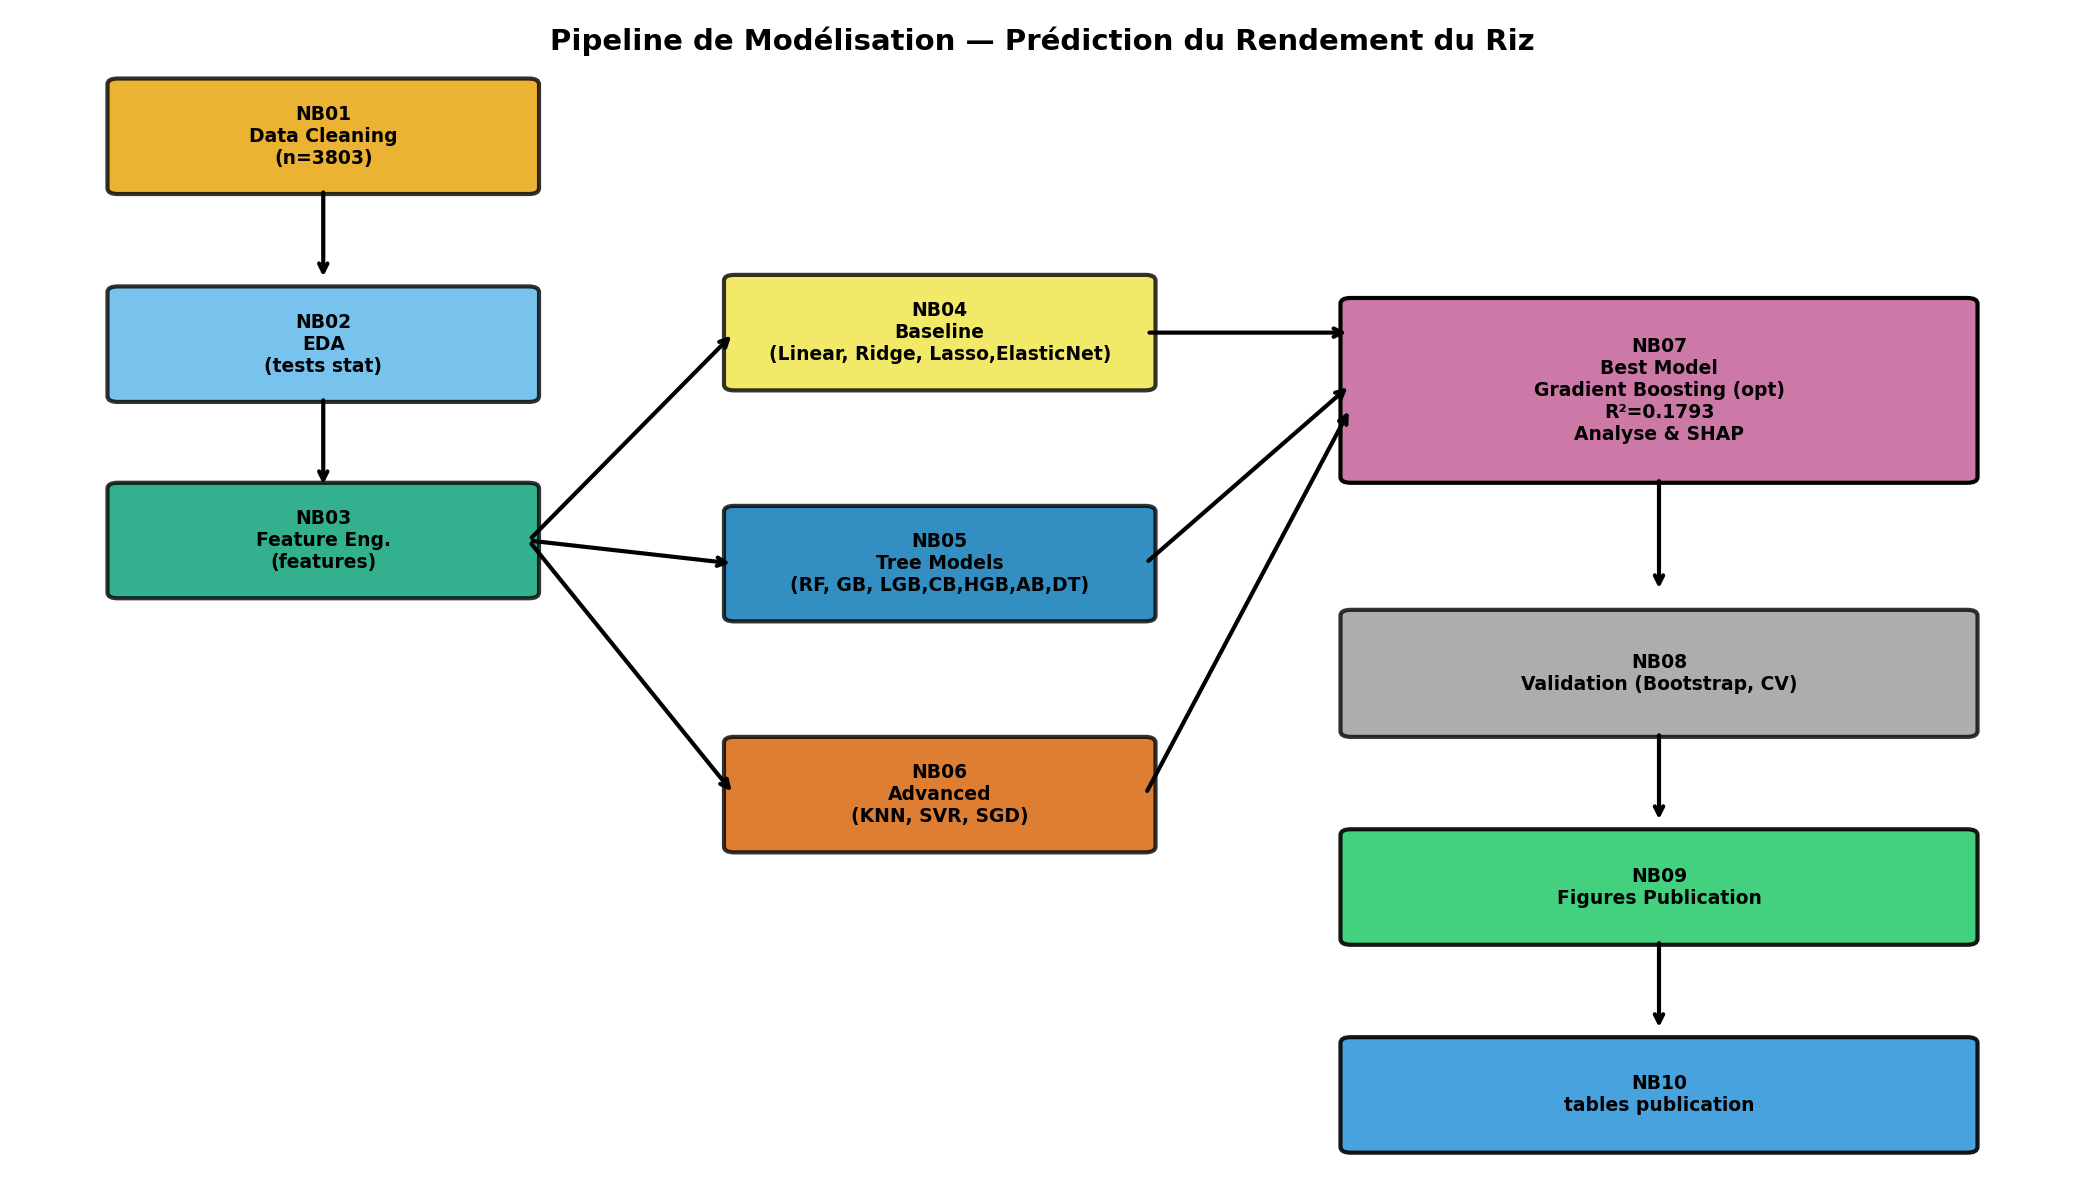

✅ Figure 1 : ../figures/publication/Figure1_pipeline.png + .pdf


In [17]:
# ============================================================
# 2. FIGURE 1 : DIAGRAMME MÉTHODOLOGIQUE (PIPELINE)
# ============================================================
print("\n" + "=" * 80)
print("📊 FIGURE 1 : PIPELINE MÉTHODOLOGIQUE")
print("=" * 80)

fig = plt.figure(figsize=(14, 8))
ax_main = fig.add_subplot(1, 1, 1)
ax_main.axis('off')
ax_main.set_xlim(0, 10)
ax_main.set_ylim(0, 10)

def draw_box(ax, x, y, w, h, text, color, alpha=0.8):
    box = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.05",
                          edgecolor='black', facecolor=color, alpha=alpha, linewidth=2)
    ax.add_patch(box)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center',
            fontsize=9, fontweight='bold')

def draw_arrow(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', lw=2, color='black'))

# Colonne gauche — préparation
draw_box(ax_main, 0.5, 8.5, 2, 0.9, 'NB01\nData Cleaning\n(n=3803)',    colors_cb[0])
draw_arrow(ax_main, 1.5, 8.5, 1.5, 7.7)
draw_box(ax_main, 0.5, 6.7, 2, 0.9, 'NB02\nEDA\n(tests stat)',           colors_cb[1])
draw_arrow(ax_main, 1.5, 6.7, 1.5, 5.9)
draw_box(ax_main, 0.5, 5.0, 2, 0.9, 'NB03\nFeature Eng.\n(features)',    colors_cb[2])
draw_arrow(ax_main, 2.5, 5.45, 3.5, 7.25)
draw_arrow(ax_main, 2.5, 5.45, 3.5, 5.25)
draw_arrow(ax_main, 2.5, 5.45, 3.5, 3.25)

# Colonne milieu — modèles
draw_box(ax_main, 3.5, 6.8, 2, 0.9, 'NB04\nBaseline\n(Linear, Ridge, Lasso,ElasticNet)', colors_cb[3])
draw_box(ax_main, 3.5, 4.8, 2, 0.9, 'NB05\nTree Models\n(RF, GB, LGB,CB,HGB,AB,DT)',        colors_cb[4])
draw_box(ax_main, 3.5, 2.8, 2, 0.9, 'NB06\nAdvanced\n(KNN, SVR, SGD)',         colors_cb[5])

draw_arrow(ax_main, 5.5, 7.25, 6.5, 7.25)
draw_arrow(ax_main, 5.5, 5.25, 6.5, 6.8)
draw_arrow(ax_main, 5.5, 3.25, 6.5, 6.6)

# Colonne droite — résultats
draw_box(ax_main, 6.5, 6.0, 3, 1.5,
         f'NB07\nBest Model\n{best_model_name}\nR²={results_all.iloc[0]["R2_Test"]:.4f}\nAnalyse & SHAP',
         colors_cb[6], alpha=1.0)
draw_arrow(ax_main, 8.0, 6.0, 8.0, 5.0)
draw_box(ax_main, 6.5, 3.8, 3, 1.0, 'NB08\nValidation (Bootstrap, CV)',                   colors_cb[7])
draw_arrow(ax_main, 8.0, 3.8, 8.0, 3.0)
draw_box(ax_main, 6.5, 2.0, 3, 0.9, 'NB09\nFigures Publication',         '#2ecc71', alpha=0.9)
draw_arrow(ax_main, 8.0, 2.0, 8.0, 1.2)
draw_box(ax_main, 6.5, 0.2, 3, 0.9, 'NB10\ntables publication',               '#3498db', alpha=0.9)

ax_main.text(5, 9.7, 'Pipeline de Modélisation — Prédiction du Rendement du Riz',
             ha='center', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/publication/Figure1_pipeline.png', dpi=300, bbox_inches='tight')
plt.savefig('../figures/publication/Figure1_pipeline.pdf', bbox_inches='tight')
plt.show()
print("✅ Figure 1 : ../figures/publication/Figure1_pipeline.png + .pdf")


📊 FIGURE 2 : PERFORMANCES COMPARÉES


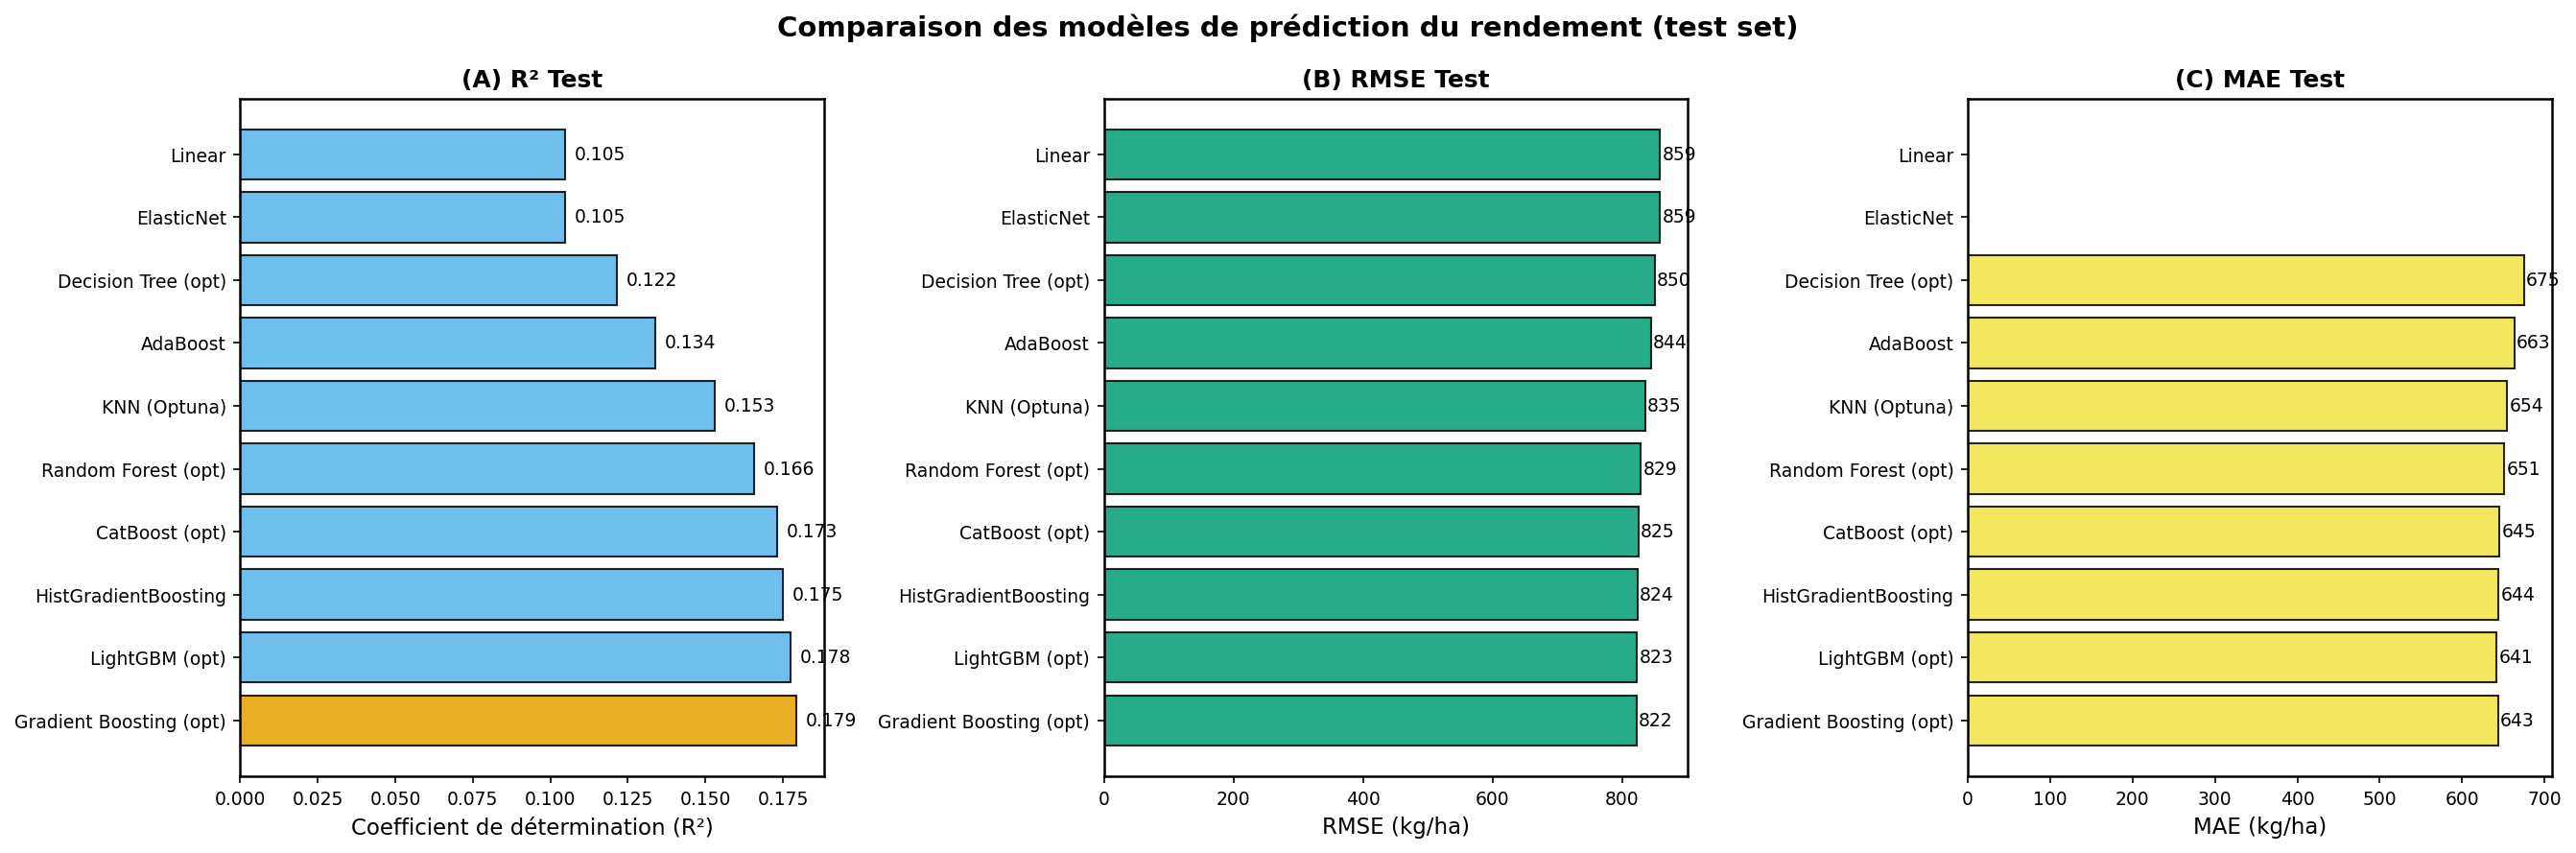

✅ Figure 2 : ../figures/publication/Figure2_model_comparison.png + .pdf


In [4]:
# ============================================================
# 3. FIGURE 2 : PERFORMANCES COMPARÉES (TOP 10 MODÈLES)
# ============================================================
print("\n" + "=" * 80)
print("📊 FIGURE 2 : PERFORMANCES COMPARÉES")
print("=" * 80)

top10 = results_all.head(10).copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Comparaison des modèles de prédiction du rendement (test set)',
             fontsize=14, fontweight='bold')

# (A) R²
ax = axes[0]
colors_bars = [colors_cb[0] if i==0 else colors_cb[1] for i in range(len(top10))]
bars = ax.barh(top10['Modèle'], top10['R2_Test'], color=colors_bars,
               edgecolor='black', alpha=0.85)
ax.set_xlabel('Coefficient de détermination (R²)', fontsize=11)
ax.set_title('(A) R² Test', fontsize=12, fontweight='bold')
ax.axvline(0, color='black', lw=0.8)
for bar, val in zip(bars, top10['R2_Test']):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

# (B) RMSE
ax = axes[1]
bars2 = ax.barh(top10['Modèle'], top10['RMSE_Test'], color=colors_cb[2],
                edgecolor='black', alpha=0.85)
ax.set_xlabel('RMSE (kg/ha)', fontsize=11)
ax.set_title('(B) RMSE Test', fontsize=12, fontweight='bold')
for bar, val in zip(bars2, top10['RMSE_Test']):
    ax.text(val + 3, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=9)

# (C) MAE
ax = axes[2]
# MAE_Test peut être absente pour certains modèles
if 'MAE_Test' in top10.columns:
    mae_vals = top10['MAE_Test'].fillna(0)
    bars3 = ax.barh(top10['Modèle'], mae_vals, color=colors_cb[3],
                    edgecolor='black', alpha=0.85)
    ax.set_xlabel('MAE (kg/ha)', fontsize=11)
    ax.set_title('(C) MAE Test', fontsize=12, fontweight='bold')
    for bar, val in zip(bars3, mae_vals):
        if val > 0:
            ax.text(val + 3, bar.get_y() + bar.get_height()/2,
                    f'{val:.0f}', va='center', fontsize=9)
else:
    ax.text(0.5, 0.5, 'MAE non disponible', ha='center', va='center',
            transform=ax.transAxes, fontsize=12)
    ax.set_title('(C) MAE Test', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/publication/Figure2_model_comparison.png', dpi=300, bbox_inches='tight')
plt.savefig('../figures/publication/Figure2_model_comparison.pdf', bbox_inches='tight')
plt.show()
print("✅ Figure 2 : ../figures/publication/Figure2_model_comparison.png + .pdf")


📊 FIGURE 3 : FEATURE IMPORTANCE + SHAP
   SHAP image chargée : ../figures/08_shap_summary_dot.png


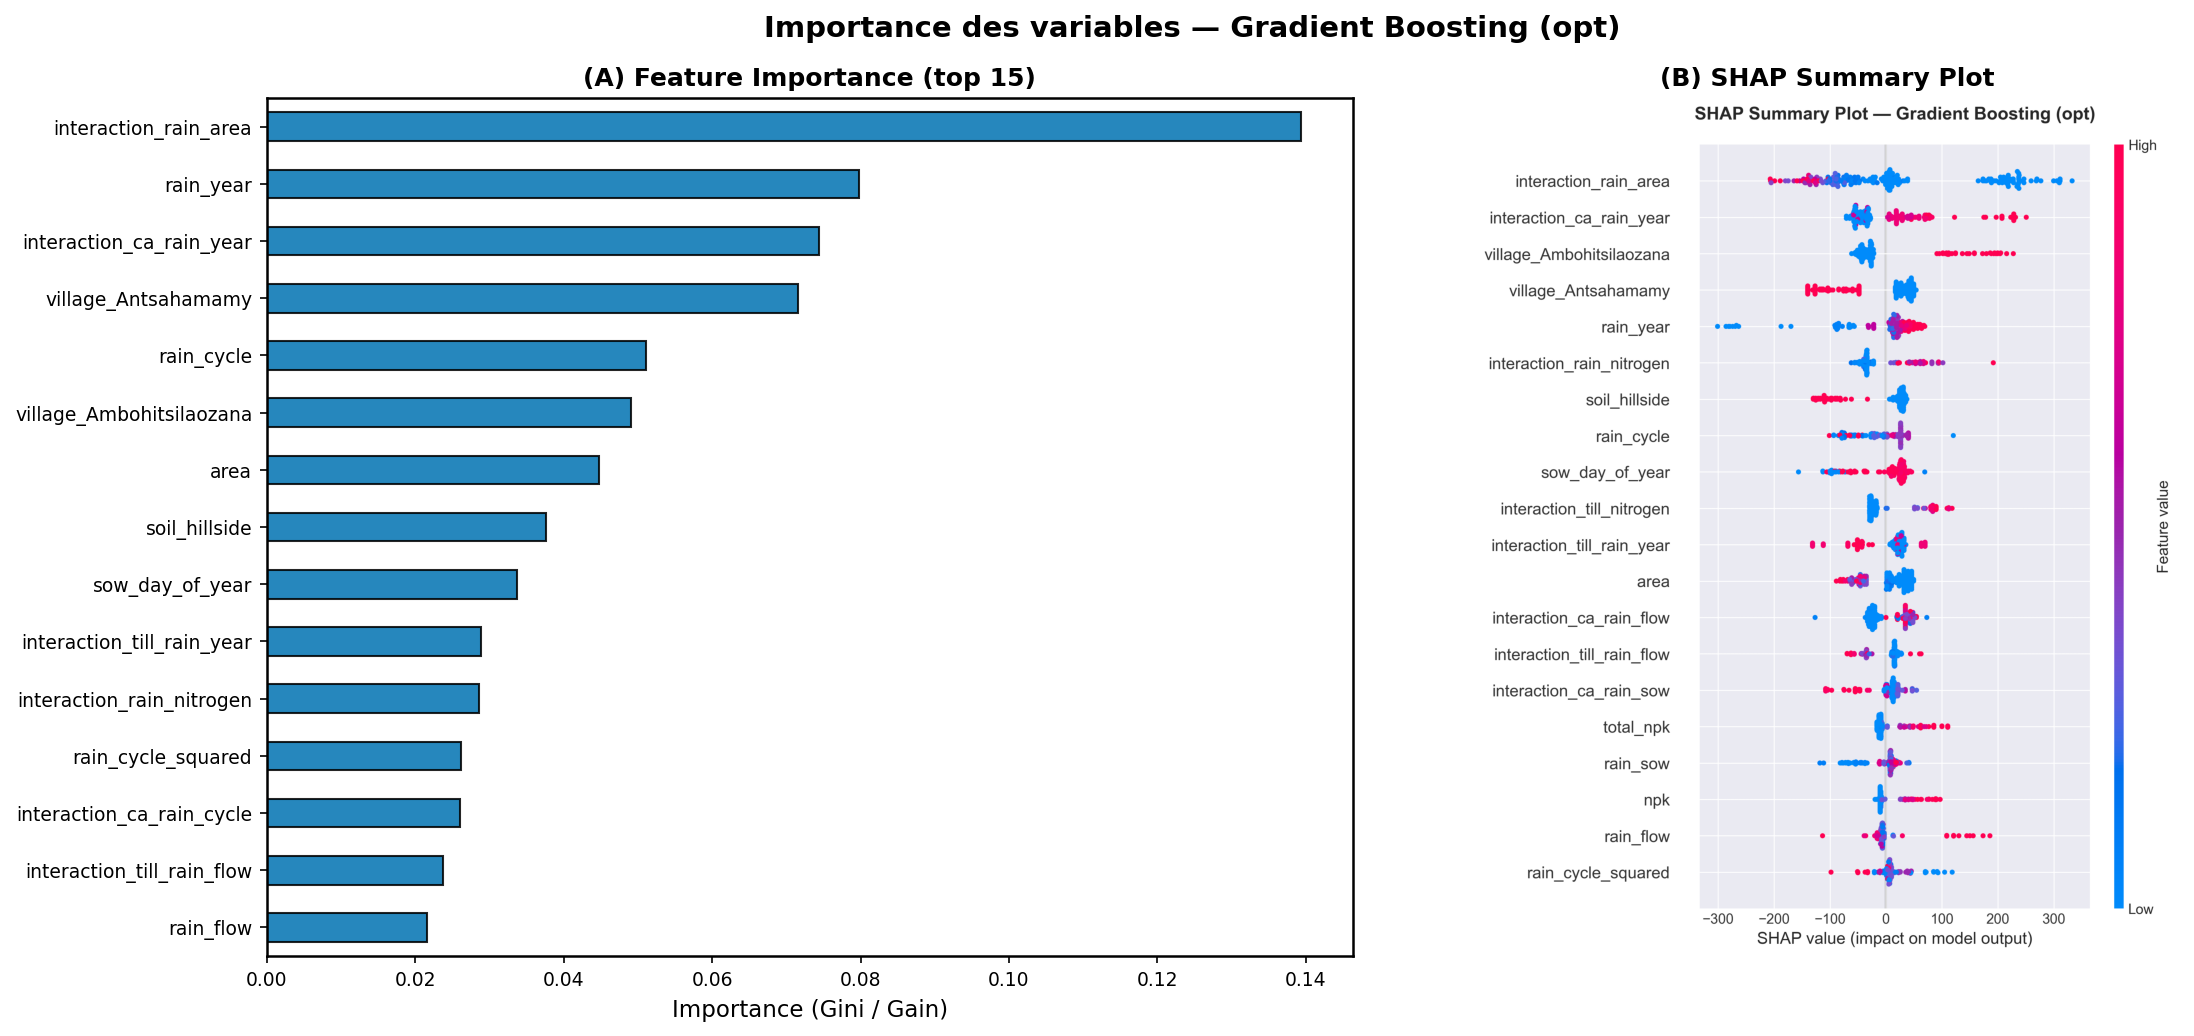

✅ Figure 3 : ../figures/publication/Figure3_feature_importance.png + .pdf


In [5]:
# ============================================================
# 4. FIGURE 3 : FEATURE IMPORTANCE + SHAP (MEILLEUR MODÈLE)
# ============================================================
print("\n" + "=" * 80)
print("📊 FIGURE 3 : FEATURE IMPORTANCE + SHAP")
print("=" * 80)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(f'Importance des variables — {best_model_name}',
             fontsize=14, fontweight='bold')

# (A) Feature Importance
ax = axes[0]
if hasattr(best_model, 'feature_importances_'):
    fi = pd.Series(best_model.feature_importances_, index=X_train.columns)
    fi = fi.sort_values(ascending=False).head(15)
    fi.plot(kind='barh', ax=ax, color=colors_cb[4], edgecolor='black', alpha=0.85)
    ax.set_xlabel('Importance (Gini / Gain)', fontsize=11)
    ax.set_title('(A) Feature Importance (top 15)', fontsize=12, fontweight='bold')
    ax.invert_yaxis()
else:
    ax.text(0.5, 0.5, 'Feature Importance\nnon disponible\n(modèle non tree-based)',
            ha='center', va='center', transform=ax.transAxes, fontsize=12)
    ax.set_title('(A) Feature Importance', fontsize=12, fontweight='bold')

# (B) SHAP Summary — cherche dans NB08
ax = axes[1]
shap_paths = [
    '../figures/08_shap_summary_dot.png',
    '../figures/08_shap_summary_plot.png',
    '../figures/07_shap_summary_plot.png',
]
shap_found = None
for p in shap_paths:
    if os.path.exists(p):
        shap_found = p
        break

if shap_found:
    from PIL import Image
    img = Image.open(shap_found)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title('(B) SHAP Summary Plot', fontsize=12, fontweight='bold')
    print(f"   SHAP image chargée : {shap_found}")
else:
    ax.text(0.5, 0.5, 'SHAP Summary Plot\n(généré dans NB08)',
            ha='center', va='center', transform=ax.transAxes, fontsize=12)
    ax.set_title('(B) SHAP Summary Plot', fontsize=12, fontweight='bold')
    ax.axis('off')
    print("   ⚠️  SHAP image non trouvée — exécutez NB08 d'abord")

plt.tight_layout()
plt.savefig('../figures/publication/Figure3_feature_importance.png', dpi=300, bbox_inches='tight')
plt.savefig('../figures/publication/Figure3_feature_importance.pdf', bbox_inches='tight')
plt.show()
print("✅ Figure 3 : ../figures/publication/Figure3_feature_importance.png + .pdf")


📊 FIGURE 4 : PRÉDICTIONS vs OBSERVATIONS


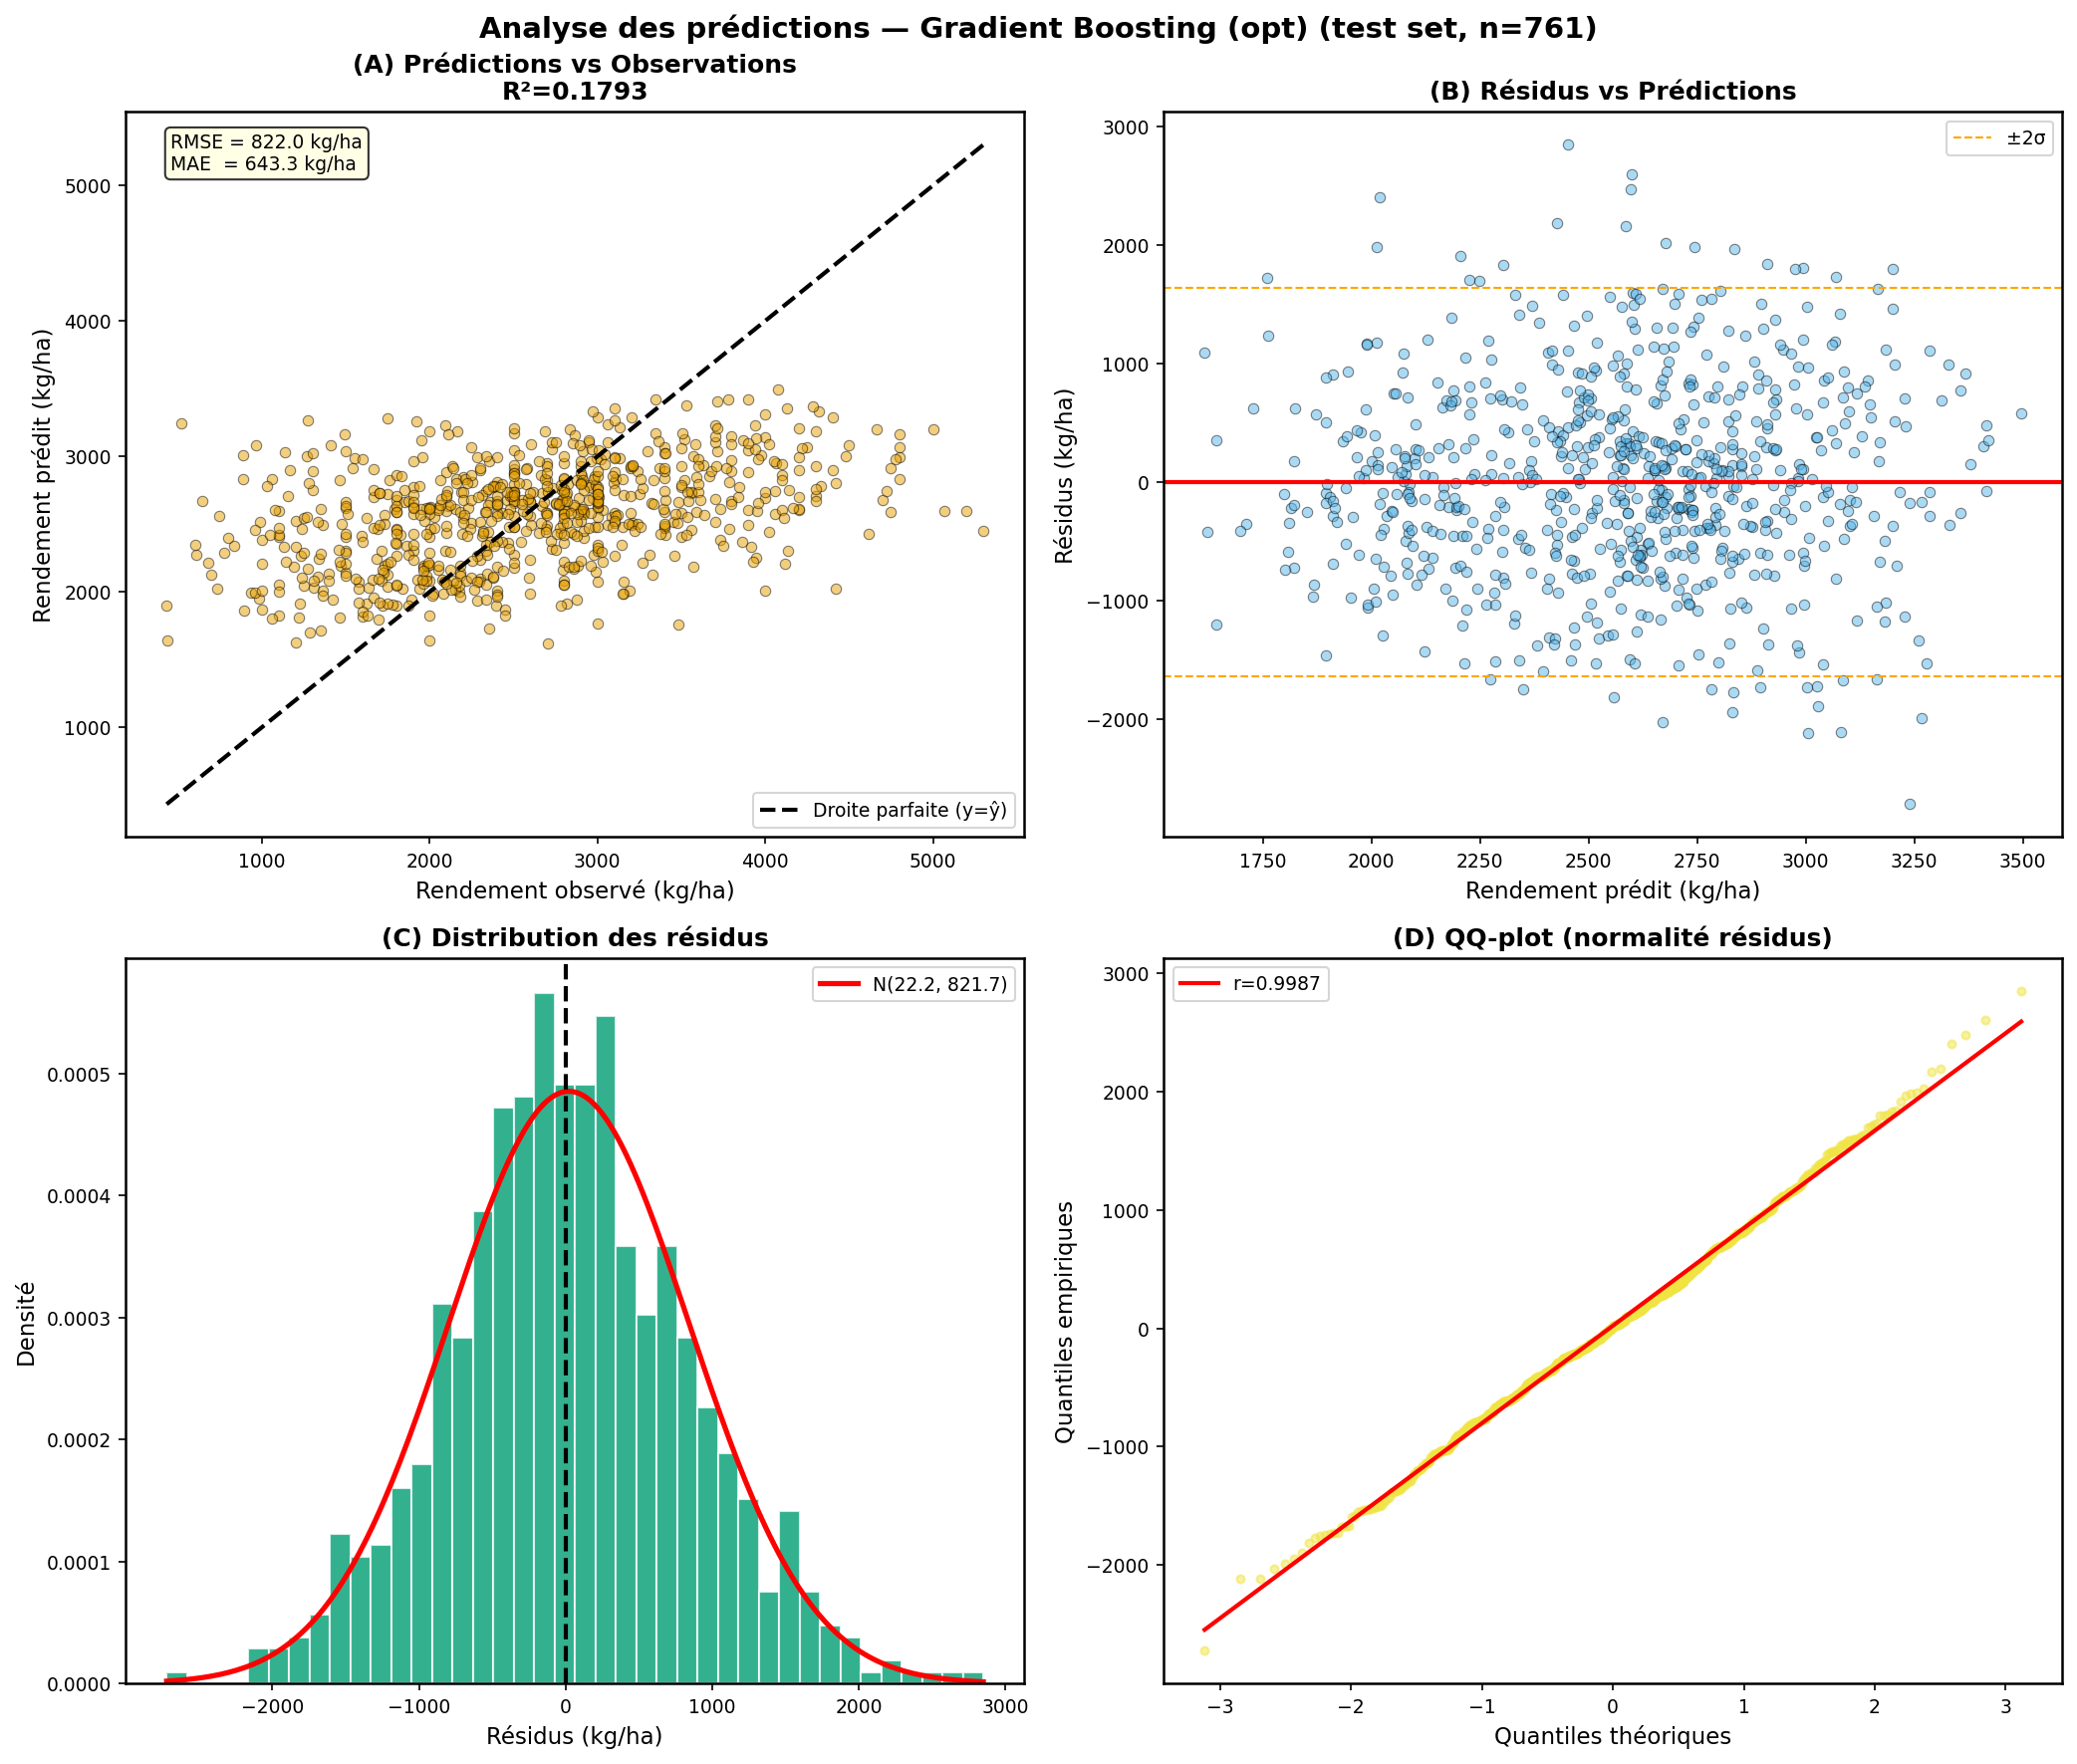

✅ Figure 4 : ../figures/publication/Figure4_predictions_analysis.png + .pdf


In [6]:
# ============================================================
# 5. FIGURE 4 : PRÉDICTIONS vs OBSERVATIONS (4 PANNEAUX)
# ============================================================
print("\n" + "=" * 80)
print("📊 FIGURE 4 : PRÉDICTIONS vs OBSERVATIONS")
print("=" * 80)

r2_test   = r2_score(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae_test  = mean_absolute_error(y_test, y_test_pred)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle(f'Analyse des prédictions — {best_model_name} (test set, n={len(y_test)})',
             fontsize=14, fontweight='bold')

# (A) Scatter prédictions vs observations
ax = axes[0, 0]
ax.scatter(y_test, y_test_pred, alpha=0.5, s=25,
           color=colors_cb[0], edgecolors='black', linewidths=0.5)
lims = [min(y_test.min(), y_test_pred.min()), max(y_test.max(), y_test_pred.max())]
ax.plot(lims, lims, 'k--', lw=2, label='Droite parfaite (y=ŷ)')
ax.set_xlabel('Rendement observé (kg/ha)', fontsize=11)
ax.set_ylabel('Rendement prédit (kg/ha)', fontsize=11)
ax.set_title(f'(A) Prédictions vs Observations\nR²={r2_test:.4f}',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.text(0.05, 0.92, f'RMSE = {rmse_test:.1f} kg/ha\nMAE  = {mae_test:.1f} kg/ha',
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# (B) Résidus vs prédictions
ax = axes[0, 1]
ax.scatter(y_test_pred, residuals, alpha=0.5, s=25,
           color=colors_cb[1], edgecolors='black', linewidths=0.5)
ax.axhline(0, color='red', lw=2)
ax.axhline( residuals.std()*2, color='orange', lw=1, linestyle='--', label='±2σ')
ax.axhline(-residuals.std()*2, color='orange', lw=1, linestyle='--')
ax.set_xlabel('Rendement prédit (kg/ha)', fontsize=11)
ax.set_ylabel('Résidus (kg/ha)', fontsize=11)
ax.set_title('(B) Résidus vs Prédictions', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

# (C) Distribution des résidus
ax = axes[1, 0]
ax.hist(residuals, bins=40, color=colors_cb[2], edgecolor='white', alpha=0.8, density=True)
mu_res, std_res = residuals.mean(), residuals.std()
xr = np.linspace(residuals.min(), residuals.max(), 200)
ax.plot(xr, norm.pdf(xr, mu_res, std_res), 'r-', lw=2.5,
        label=f'N({mu_res:.1f}, {std_res:.1f})')
ax.axvline(0, color='black', lw=2, linestyle='--')
ax.set_xlabel('Résidus (kg/ha)', fontsize=11)
ax.set_ylabel('Densité', fontsize=11)
ax.set_title('(C) Distribution des résidus', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

# (D) QQ-plot
ax = axes[1, 1]
(osm, osr), (slope, intercept, r_qq) = probplot(residuals, dist='norm')
ax.scatter(osm, osr, alpha=0.5, s=15, color=colors_cb[3])
ax.plot(osm, slope*np.array(osm)+intercept, 'r-', lw=2, label=f'r={r_qq:.4f}')
ax.set_xlabel('Quantiles théoriques', fontsize=11)
ax.set_ylabel('Quantiles empiriques', fontsize=11)
ax.set_title('(D) QQ-plot (normalité résidus)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../figures/publication/Figure4_predictions_analysis.png', dpi=300, bbox_inches='tight')
plt.savefig('../figures/publication/Figure4_predictions_analysis.pdf', bbox_inches='tight')
plt.show()
print("✅ Figure 4 : ../figures/publication/Figure4_predictions_analysis.png + .pdf")


📊 FIGURE 5 : VALIDATION CROISÉE + BOOTSTRAP


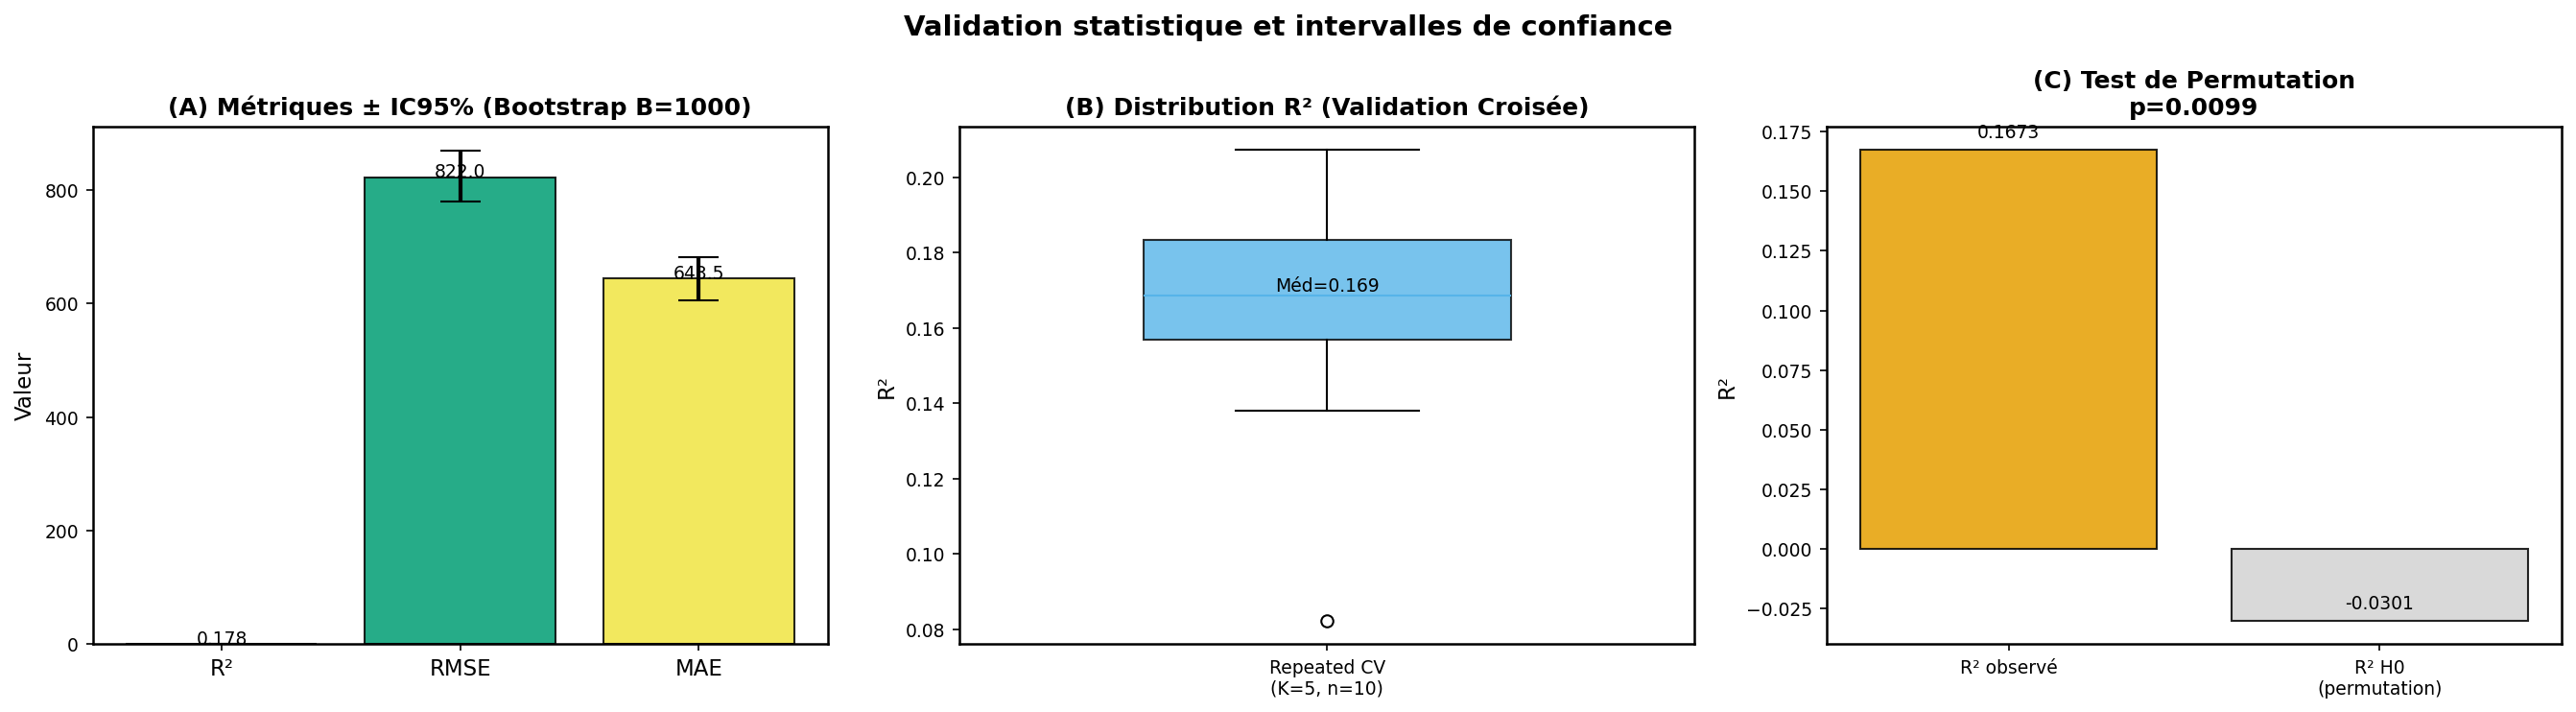

✅ Figure 5 : ../figures/publication/Figure5_validation_statistics.png + .pdf


In [7]:
# ============================================================
# 6. FIGURE 5 : VALIDATION CROISÉE + BOOTSTRAP (depuis NB09)
# ============================================================
print("\n" + "=" * 80)
print("📊 FIGURE 5 : VALIDATION CROISÉE + BOOTSTRAP")
print("=" * 80)

if boot_stats is not None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Validation statistique et intervalles de confiance',
                 fontsize=14, fontweight='bold')

    # (A) Métriques ± IC95%
    ax = axes[0]
    metrics = boot_stats['Métrique'].values
    means   = boot_stats['Moyenne'].values
    ic_inf  = boot_stats['IC95_inf'].values
    ic_sup  = boot_stats['IC95_sup'].values
    yerr    = [means - ic_inf, ic_sup - means]
    x_pos   = np.arange(len(metrics))
    bars = ax.bar(x_pos, means, color=[colors_cb[0], colors_cb[2], colors_cb[3]],
                  edgecolor='black', alpha=0.85, yerr=yerr, capsize=10,
                  error_kw={'lw':2})
    ax.set_xticks(x_pos)
    ax.set_xticklabels(metrics, fontsize=11)
    ax.set_ylabel('Valeur', fontsize=11)
    ax.set_title('(A) Métriques ± IC95% (Bootstrap B=1000)', fontsize=12, fontweight='bold')
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2,
                val + (ic_sup[0]-means[0])*0.1,
                f'{val:.3f}' if val < 10 else f'{val:.1f}',
                ha='center', fontsize=9)

    # (B) Distribution R² CV répétée
    ax = axes[1]
    cv_path = '../results/09_repeated_cv_scores.csv'
    if os.path.exists(cv_path):
        cv_scores = pd.read_csv(cv_path)
        ax.boxplot([cv_scores['R2_test'].values], positions=[1], widths=0.5,
                   patch_artist=True, boxprops=dict(facecolor=colors_cb[1], alpha=0.8))
        ax.text(1, cv_scores['R2_test'].median(),
                f'Méd={cv_scores["R2_test"].median():.3f}',
                ha='center', va='bottom', fontsize=9)
        ax.set_xticks([1])
        ax.set_xticklabels(['Repeated CV\n(K=5, n=10)'])
        ax.set_ylabel('R²', fontsize=11)
        ax.set_title('(B) Distribution R² (Validation Croisée)', fontsize=12, fontweight='bold')
    else:
        ax.text(0.5, 0.5, 'CV scores\nnon disponibles\n(NB09 non exécuté)',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title('(B) Validation Croisée', fontsize=12, fontweight='bold')

    # (C) Test de permutation
    ax = axes[2]
    perm_path = '../results/09_permutation_test.csv'
    if os.path.exists(perm_path):
        perm_res     = pd.read_csv(perm_path)
        r2_obs       = perm_res['R2_observed'].values[0]
        r2_perm_mean = perm_res['R2_perm_mean'].values[0]
        p_val        = perm_res['p_value'].values[0]
        ax.bar([1, 2], [r2_obs, r2_perm_mean],
               color=[colors_cb[0], 'lightgray'], edgecolor='black', alpha=0.85)
        ax.set_xticks([1, 2])
        ax.set_xticklabels(['R² observé', 'R² H0\n(permutation)'])
        ax.set_ylabel('R²', fontsize=11)
        ax.set_title(f'(C) Test de Permutation\np={p_val:.4f}',
                     fontsize=12, fontweight='bold')
        ax.text(1, r2_obs + 0.005, f'{r2_obs:.4f}', ha='center', fontsize=9)
        ax.text(2, r2_perm_mean + 0.005, f'{r2_perm_mean:.4f}', ha='center', fontsize=9)
    else:
        ax.text(0.5, 0.5, 'Test de permutation\nnon disponible\n(NB09 non exécuté)',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title('(C) Test de Permutation', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.savefig('../figures/publication/Figure5_validation_statistics.png', dpi=300, bbox_inches='tight')
    plt.savefig('../figures/publication/Figure5_validation_statistics.pdf', bbox_inches='tight')
    plt.show()
    print("✅ Figure 5 : ../figures/publication/Figure5_validation_statistics.png + .pdf")
else:
    print("⚠️  Figure 5 ignorée — NB09 non exécuté (pas de stats bootstrap)")
    print("   → Exécutez d'abord le notebook 09_validation.ipynb")

In [10]:
# ============================================================
# 7. RÉSUMÉ + CHECKLIST
# ============================================================
print("\n" + "=" * 80)
print("📝 RÉSUMÉ — FIGURES PUBLICATION")
print("=" * 80)

figures_list = [
    'Figure1_pipeline.png / .pdf',
    'Figure2_model_comparison.png / .pdf',
    'Figure3_feature_importance.png / .pdf',
    'Figure4_predictions_analysis.png / .pdf',
]
if boot_stats is not None:
    figures_list.append('Figure5_validation_statistics.png / .pdf')

summary = (
    "FIGURES HAUTE QUALITÉ POUR PUBLICATION\n"
    + "="*70 + "\n\n"
    + "Répertoire : ../figures/publication/\n\n"
    + "FIGURES GÉNÉRÉES :\n"
    + "\n".join(f"  {i+1}. {f}" for i, f in enumerate(figures_list))
    + "\n\nSPÉCIFICATIONS TECHNIQUES :\n"
    + "  - Résolution : 300 DPI\n"
    + "  - Formats    : PNG (preview) + PDF (vectoriel)\n"
    + "  - Palette    : Okabe & Ito (colorblind-safe)\n"
    + "  - Police     : DejaVu Sans, ≥9pt\n"
    + "  - Dimensions : optimisées pour colonnes double (18 cm)\n\n"
    + "CONFORMITÉ :\n"
    + "  ✅ Nature/Science : résolution ≥300 DPI\n"
    + "  ✅ PLOS journals  : formats .eps, .pdf, .png acceptés\n"
    + "  ✅ Accessibilité  : palette colorblind-friendly\n\n"
    + "="*70 + "\n"
)

print(summary)
with open('../results/09_figures_publication_summary.txt', 'w', encoding='utf-8') as f:
    f.write(summary)
print("\n✅ ../results/09_figures_publication_summary.txt")

# ── CHECKLIST ─────────────────────────────────────────────────────────────────
print("\n" + "=" * 80)
print("✅ CHECKLIST — NOTEBOOK 09")
print("=" * 80)

checklist = [
    ("Données et modèle chargés",           all(x in globals() for x in ['X_train','best_model','y_test_pred'])),
    ("Figure 1 : Pipeline (PNG)",           os.path.exists('../figures/publication/Figure1_pipeline.png')),
    ("Figure 1 : Pipeline (PDF)",           os.path.exists('../figures/publication/Figure1_pipeline.pdf')),
    ("Figure 2 : Comparaison modèles (PNG)",os.path.exists('../figures/publication/Figure2_model_comparison.png')),
    ("Figure 2 : Comparaison modèles (PDF)",os.path.exists('../figures/publication/Figure2_model_comparison.pdf')),
    ("Figure 3 : Feature Importance (PNG)", os.path.exists('../figures/publication/Figure3_feature_importance.png')),
    ("Figure 3 : Feature Importance (PDF)", os.path.exists('../figures/publication/Figure3_feature_importance.pdf')),
    ("Figure 4 : Prédictions (PNG)",        os.path.exists('../figures/publication/Figure4_predictions_analysis.png')),
    ("Figure 4 : Prédictions (PDF)",        os.path.exists('../figures/publication/Figure4_predictions_analysis.pdf')),
    ("Figure 5 : Validation (PNG)",         os.path.exists('../figures/publication/Figure5_validation_statistics.png')),
    ("Figure 5 : Validation (PDF)",         os.path.exists('../figures/publication/Figure5_validation_statistics.pdf')),
    ("Résumé 09_figures_publication.txt",   os.path.exists('../results/09_figures_publication_summary.txt')),
]

completed = 0
for item, status in checklist:
    print(f"   {'✅' if status else '❌'} {item}")
    if status: completed += 1

print(f"\n{'='*80}")
print(f"📊 PROGRESSION : {completed}/{len(checklist)} ({completed*100//len(checklist)}%)")
if completed >= 9:
    print("🎉 NOTEBOOK 9 TERMINÉ — Figures publication générées !")
    print(f"\n🏆 Meilleur modèle : {best_model_name}")
    print(f"   R² Test = {results_all.iloc[0]['R2_Test']:.4f}")
    print(f"\n📁 Figures disponibles dans : ../figures/publication/")
else:
    missing = [item for item, status in checklist if not status]
    print(f"\n⚠️  {len(missing)} élément(s) manquant(s):")
    for item in missing:
        print(f"   ❌ {item}")
print("=" * 80)


📝 RÉSUMÉ — FIGURES PUBLICATION
FIGURES HAUTE QUALITÉ POUR PUBLICATION

Répertoire : ../figures/publication/

FIGURES GÉNÉRÉES :
  1. Figure1_pipeline.png / .pdf
  2. Figure2_model_comparison.png / .pdf
  3. Figure3_feature_importance.png / .pdf
  4. Figure4_predictions_analysis.png / .pdf
  5. Figure5_validation_statistics.png / .pdf

SPÉCIFICATIONS TECHNIQUES :
  - Résolution : 300 DPI
  - Formats    : PNG (preview) + PDF (vectoriel)
  - Palette    : Okabe & Ito (colorblind-safe)
  - Police     : DejaVu Sans, ≥9pt
  - Dimensions : optimisées pour colonnes double (18 cm)

CONFORMITÉ :
  ✅ Nature/Science : résolution ≥300 DPI
  ✅ PLOS journals  : formats .eps, .pdf, .png acceptés
  ✅ Accessibilité  : palette colorblind-friendly



✅ ../results/10_figures_publication_summary.txt

✅ CHECKLIST — NOTEBOOK 09
   ✅ Données et modèle chargés
   ✅ Figure 1 : Pipeline (PNG)
   ✅ Figure 1 : Pipeline (PDF)
   ✅ Figure 2 : Comparaison modèles (PNG)
   ✅ Figure 2 : Comparaison modèles (PDF)
   ✅ Fi